# [LAB-02] 비지도 학습ㅣ01-차원축소(실습코드).ipynb 

## 비지도학습(Unsupervised Learning)이란?

□ 라벨(정답) 없이 데이터에 숨겨진 구조나 패턴을 스스로 찾아내는 기계학습 방법

| | 지도학습 (Supervised) | 비지도학습 (Unsupervised) |
|---|---|---|
| 정답(라벨) | 있음 (제공됨) | 없음 (제공되지 않음) |
| 주요 목적 | 특정 변수의 예측 및 분류 | 데이터의 숨겨진 구조 발견 |
| 활용 예시 | 스팸 메일 분류, 주택 가격 예측 | 고객 그룹 세분화, 이상 탐지 |
| 모형 평가 | 정답과 비교하여 명확히 평가 | 지표·해석 기반으로 다소 모호함 |
| 종류 | 선형회귀, 로지스틱 회귀, 의사결정나무, 랜덤포레스트, XGBoost, LightGBM, CatBoost 등 | **군집분석(KMeans, DBScan 등)**<br>**차원축소(PCA)** |

□ 비지도학습의 3가지 핵심 특징

- **분석가의 판단 중요** — 도메인 지식과 주관적 해석이 결과에 큰 영향을 미침
- **모호한 평가 기준** — 명확한 정답이 없기 때문에 해석과 검증 과정이 필수적
- **구조 및 패턴 탐색** — 데이터 속 숨겨진 군집이나 특징을 직관적으로 발견

---

## 차원축소란 무엇인가

□ 정보를 최대한 지키면서 변수(열)의 개수를 줄이는 작업
◎ 데이터 전처리 과정에 해당한다고 볼 수 있다.

`10행 × 7열` → (변수 3개를 빼면) → `10행 × 4열`

데이터 분석 과정에서 모델에 투입할 특성(독립변수)를 선정하는 방법

| 구분 | 하는 일 | PCA와의 관계 |
|---|---|---|
| 특성 선택 | 중요한 변수만 남긴다 | 해당 없음 |
| 특성 추출 | 변수들을 조합해 새 변수를 만든다 | PCA가 여기에 해당 |

---

## PCA의 아이디어

□ 데이터가 가장 넓게 퍼진 방향을 찾아, 그 방향을 새로운 축으로 삼는다

데이터가 가장 많이 퍼져 있는(=분산이 큰) 방향에 정보가 가장 많이 들어 있다.

그 방향을 첫 번째 새 축(PC1)으로 삼고, 그다음으로 많이 퍼진 방향을 PC2로 삼는다.

새로 만든 변수 이름은 관례적으로 PC1, PC2, … PCn

원래 변수 하나하나의 의미는 사라진다 → 대신 정보 손실을 줄이며 개수를 줄일 수 있다

(다이어그램: 가장 길게 퍼진 방향 = PC1, 그에 직각인 방향 = PC2)

---

## PCA의 장단점

□ 해석이 목적이면 쓰지 않고, 성능·구조 파악이 목적이면 쓴다

- PCA를 쓰면 변수 하나하나의 **해석을 포기**하게 된다
- 대신 변수들 사이의 관계를 반영한 **안정적인 입력 데이터**를 얻는다

**해석 중심이면 PCA ❌, 성능·구조 중심이면 PCA ⭕**

| 질문 | 답 |
|---|---|
| PCA는 무엇을 하나 | 정보를 최대한 지키면서 변수의 개수를 줄인다 |
| 왜 표준화가 필요한가 | 단위가 큰 변수 하나가 분산을 독차지하지 않도록 |
| 몇 개를 남기나 | 누적 설명력이 80%를 넘는 지점까지 (wine_qt는 PC6) |
| 언제 쓰면 안 되나 | 변수 하나하나의 해석이 목적일 때 |

---

## 데이터 분석에 PCA를 적용한 사례 (1)

□ 여러 변수를 결합하여 새로운 변수를 생성
◎ 특정 요인에 대한 설명이 아니고 어떤 경향을 설명하게 된다.

**머신러닝 기반 분석 | PCA 주성분 분석**

차원 축소 결과 — 6개의 복잡한 변수를 3개의 핵심 주성분으로 압축하여 전체 데이터 변동성의 약 82%를 설명

- **PC1(제1주성분)** — 설명력 44% : 전체 데이터의 절반 가까운 응집, 대량 구매 성향을 나타내는 가장 강력한 축<br>[Loading] 식료품(0.57) / 세제 취미향(0.55) / 유제품(0.54)
- **PC2(제2주성분)** — 설명력 27% : 신선 식품과 냉동 식재료 중심의 식습·호텔 구매 성향을 두 번째 축<br>[Loading] 신선 식품(0.579) / 냉동식품(0.58) / 세제 취미향(0.53)
- **PC3(제3주성분)** — 설명력 11% : 가정식품이나 특수 목적의 간식도로를 설명하는 보조적인 축<br>[Loading] 세제 취미향(0.72) / 신선식품(-0.63) / 세제 취미향(-0.19)

고객 데이터와 변수 간 관계 확인 | Biplot 시각화
- Biplot: 관측치(PCA점수)와 원변수(로딩) 방향을 함께 표시한 그래프
- 화살표: 변수가 주성분에 영향을 미치는 방향과 크기
- 고객 소비 패턴은 크게 "식료품 중심" vs "신선/냉동 중심"으로 구분
- 식료품·유제품·세제류는 동일한 소비군에 묶이는 강한 양의 상관관계 확인
- 변수 간 관계를 통해 고객 세분화(K-Means)의 기준이 되는 구조 확인

(출처: 아이티윌 머신러닝 부트캠프 5기 정보화 훈련생 포트폴리오에서 발췌)

---

## 데이터 분석에 PCA를 적용한 사례 (2)

□ 분석 결과의 해석 어려움
◎ 종속변수에 영향을 주는 요인이 PC1, PC2… 와 같은 형태로 도출된다.
◎ 하나의 요인은 여러 변수가 결합된 특성이므로 해석도 종합적으로만 이루어진다.

SHAP 분석 상위 3개 변수 (해석 X, 결합 결과로 요약)

| PC1 | PC8 | PC10 |
|---|---|---|
| 지역 활성도 및 유동인구 | 과속방지턱 집중 구간 | 안전 감시망 구간 |
| [주요 변수] 보행자어린이·노약자, 직장인/방문자 유동인구 | [주요 변수] 과속방지턱, 거주인구 차량속도 | [주요 변수] CCTV, 도로 길이 버스정류장 |
| [의미] 보행 통행량이 많아 사고 노출 위험이 높은 구역 특성 | [의미] 사람이 많고 과속방지턱이 집중된 구간 특성 | [의미] 길이가 짧은 도로 구간에 CCTV가 많이 설치된 단속 구역 특성 |

---

## 표준화 적용

□ 단위가 큰 변수 하나가 분산을 독차지하지 않도록 눈금을 통일해야 한다

실습 데이터 (wine_qt)의 변수별 값의 범위

| 변수 | 대략적인 값의 범위 |
|---|---|
| 알코올 도수 | 9 ~ 14 |
| 총 이산화황 | 6 ~ 289 |

**표준화**: (값 − 평균) ÷ 표준편차 → 평균 0, 표준편차 1 로 통일

표준화하지 않으면 숫자가 큰 변수 하나가 PC1을 거의 혼자 결정해 버린다

**PCA에서 표준화는 선택이 아니라 필수 과정이다**

## #01. 준비작업 
### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 

from pandas import DataFrame 

# 주성분 분석 패키지 
from sklearn.decomposition import PCA

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 

In [2]:
origin = load_data("wine_qt")   
origin.head()

📚 이 데이터셋은 와인의 화학적·물리적 특성을 나타내는 연속형 변수들과, 이를 종합해 평가한 품질 점수(quality)로 구성되어 있습니다. (출처: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)

변수                  설명
--------------------  ----------------
fixed acidity         고정 산도
volatile acidity      휘발성 산도
citric acid           구연산
residual sugar        잔당
chlorides             염화물
free sulfur dioxide   유리 아황산
total sulfur dioxide  총 아황산
density               밀도
pH                    산성도
sulphates             황산염
alcohol               알코올 도수
quality               품질 점수 (0~10)



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5


### 3. 전처리(1) - 종속변수 제거 
차원축소는 독립변수에 대해서만 적용되는 기법이다. 

In [3]:
df1 = origin.drop("quality", axis=1)
df1.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400


### 4. 전처리(2) - 데이터 스케일링 
PCA 에서는 모든 변수를 같은 눈금으로 맞추는 표준화가 필수다. 

In [4]:
# 표준화 (평균 0, 표준편차 1)
sdf = my_prep.scaling(df1, method="standard", verbose=False)
sdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.522,0.939,-1.365,-0.466,-0.231,-0.450,-0.364,0.556,1.271,-0.574,-0.963
1,-0.293,1.942,-1.365,0.050,0.234,0.916,0.643,0.036,-0.709,0.131,-0.594
2,-0.293,1.273,-1.162,-0.171,0.107,-0.060,0.247,0.140,-0.326,-0.045,-0.594
3,1.654,-1.400,1.483,-0.466,-0.253,0.135,0.430,0.660,-0.964,-0.456,-0.594
4,-0.522,0.939,-1.365,-0.466,-0.231,-0.450,-0.364,0.556,1.271,-0.574,-0.963


## 주성분 개수 결정

□ 개수를 정하는 방법은 세 가지
◎ 실무에서는 누적 설명력 기준을 가장 많이 쓴다

| 지정 방식 | 의미 |
|---|---|
| 개수 | 분석가가 숫자로 직접 지정 |
| 'mle' | 통계적 기준으로 알아서 개수를 정함 |
| 0 ~ 1 사이 비율 | 누적 설명력이 지정된 비율이 되는 개수를 정함 |

## #02. 차원 축소 
### 1. 차원축소 수행 
n_components: 주성분 개수를 설정한다\
random_state: 랜덤시드를 고정한다 (재현성을 위함)

In [5]:
estimator = PCA(n_components="mle", random_state=9901)
pca = estimator.fit_transform(sdf)
pca

array([[-1.56154478,  0.44489171, -1.76720916, ...,  0.33008582,
        -0.01154807, -0.24961113],
       [-0.76089236,  1.91505819, -0.8641578 , ..., -0.74693875,
         0.54764364,  0.00519571],
       [-0.70808539,  0.91442316, -1.14236292, ..., -0.57565201,
         0.08411791, -0.20371481],
       ...,
       [-2.12463519,  0.87380431,  0.62657264, ...,  0.35760108,
         1.00809106,  0.29669087],
       [-2.20853569,  0.92834262,  1.815403  , ...,  0.26946144,
         1.15057722,  0.43650587],
       [-2.24173343,  1.00318928,  0.65088927, ...,  0.49897478,
         0.70794013,  0.74328967]], shape=(1143, 10))

### 2. 차원 축소 결과를 데이터 프레임으로 구성 
차원축소의 컬럼 이름은 일반적으로 PC1, PC2, ....PCn 과 같이 지정한다. 

In [6]:
n = pca.shape[1] # 주성분 개수(리턴값의 열 수)

# 열 수 만큼 반복하면서 "PC1", "PC2",... 열 이름 생성 
cols = [f"PC{i+1}" for i in range(n)]

# 주성분 분석 결과를 데이터 프레임으로 변환 
pca_df = DataFrame(pca, columns=cols)
pca_df["target"] = origin["quality"]
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,target
0,-1.562,0.445,-1.767,0.133,0.130,0.907,0.122,0.330,-0.012,-0.250,5
1,-0.761,1.915,-0.864,0.537,0.091,-0.860,0.999,-0.747,0.548,0.005,5
2,-0.708,0.914,-1.142,0.435,0.025,-0.357,0.536,-0.576,0.084,-0.204,5
3,2.308,-0.224,0.257,-0.831,-1.639,0.155,-0.300,0.495,-0.110,-0.122,6
4,-1.562,0.445,-1.767,0.133,0.130,0.907,0.122,0.330,-0.012,-0.250,5


이 데이터를 선형회귀, 로지스틱회귀, 그 밖의 머신러닝(예측, 분류, 군집)의 모델링에 사용한다.
예측 성능은 데이터 원본을 사용하는 경우보다 대체로 높게 나오지만 결과 해석이 매우 어렵다.

## #03. 결과 해석 
### 1. 주성분별 설명력 

설명력 = 그 주성분 하나가 담고 있는 전체 정보의 비율 

### 2. 누적 설명력 

**누적 설명력 = 첫 번째부터 그 주성분까지 합한 비율**

| 주성분 | 설명력 | 누적 설명력 |
|---|---|---|
| PC1 | 0.287 | 0.287 |
| PC2 | 0.171 | 0.458 |
| PC3 | 0.143 | 0.601 |
| PC4 | 0.110 | 0.711 |
| PC5 | 0.087 | 0.798 |
| **PC6** | **0.060** | **0.858** |

> 누적 설명력이 80%를 넘는 지점은 **PC6** → 11개 변수를 6개로 줄일 수 있다

PC1이 28.7%, PC5까지 79.8%, PC6에서 85.8%로 80%를 넘는다

---

### 3. 누적 설명력 그래프

◎ 가로축은 주성분의 개수, 세로축은 누적 설명력이다.\
◎ **가로 점선(80%)을 처음 넘어서는 지점**이 우리가 채택할 주성분의 개수다.\
　○ 80%는 예측/분류 모형이 납득할만한 수준의 성능을 보이는 지점으로 분석가가 지정하는 임계점\
　○ 반복적인 실험을 통해 채택해야 한다.

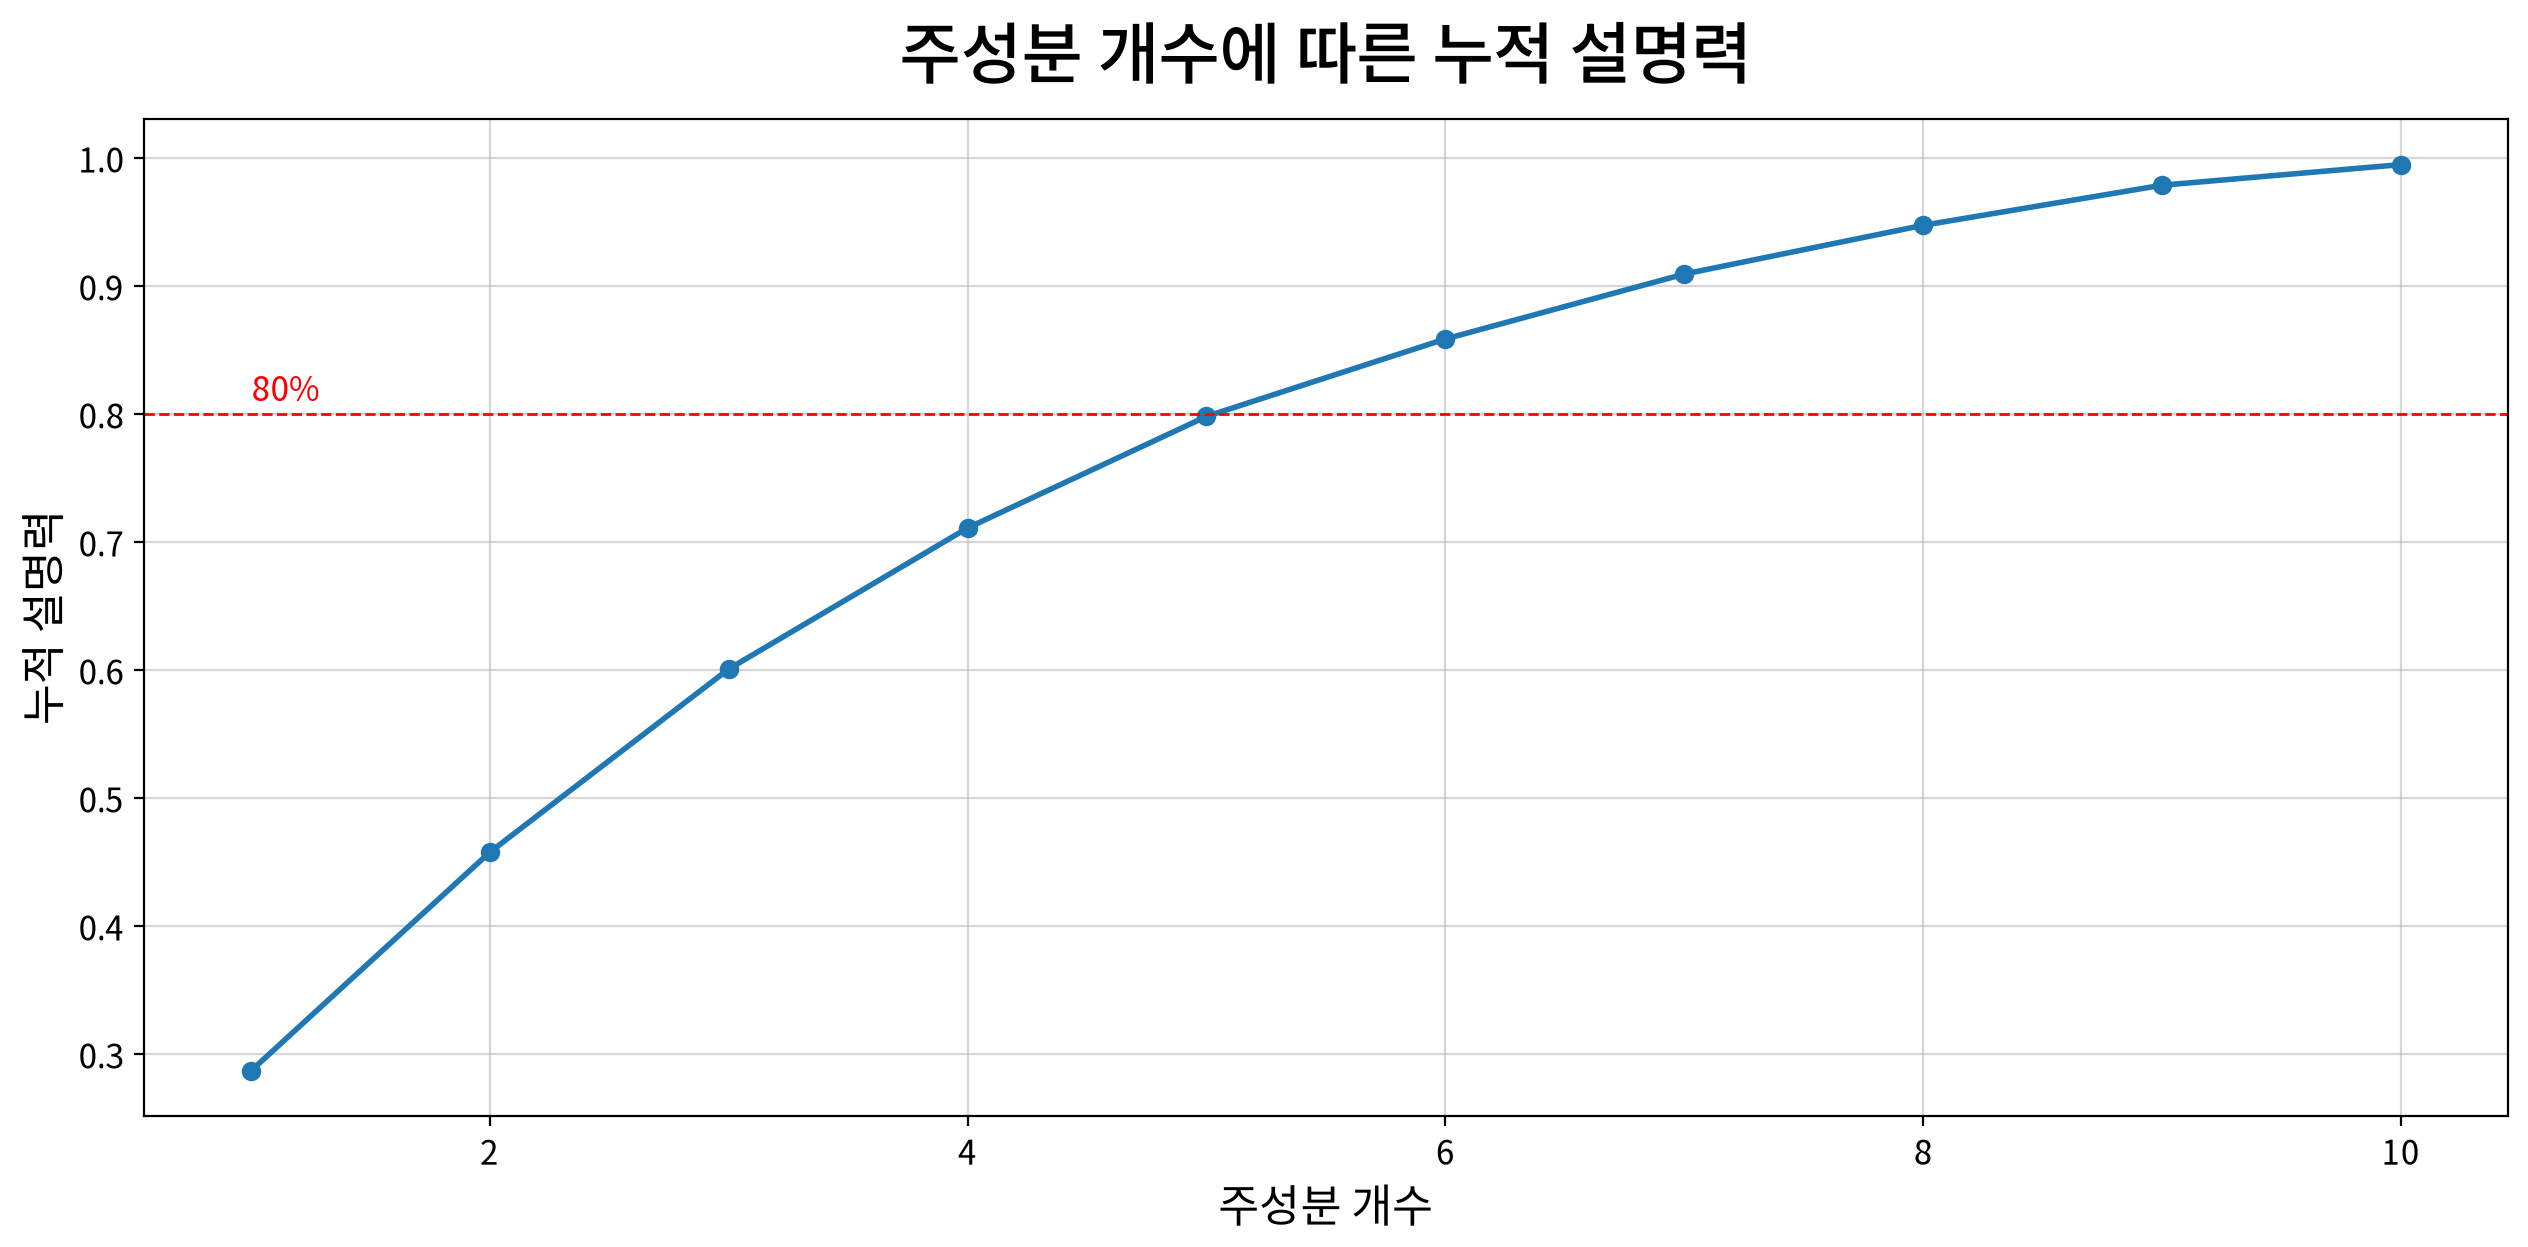

In [7]:
cum = estimator.explained_variance_ratio_.cumsum() 
k_list = list(range(1, len(cum) + 1))

fig, ax = my_plot.init(title="주성분 개수에 따른 누적 설명력", 
                       xlabel="주성분 개수", ylabel="누적 설명력")

my_plot.lineplot(x=k_list, y=cum, marker="o", ax=ax)

# 80% 기준선 
ax.axhline(0.8, color="red", linestyle="--", linewidth=1)
ax.text(1, 0.81, "80%", color="red")

my_plot.show()

## 3. 누적 설명력 그래프 (결과 확인)

**주성분 개수에 따른 누적 설명력** (그래프: x축 주성분 개수 1~10, y축 누적 설명력 0.3~1.0, 빨간 점선이 0.8 지점, PC6 부근에서 점선을 처음 넘는 곡선)

| 항목 | 내용 |
|---|---|
| 가로축 | 주성분 개수 |
| 세로축 | 누적 설명력 |
| 빨간 점선 | 80% 기준선 |
| 처음 넘는 지점 | PC6 (0.858) |

> 해석 중심이면 PCA ❌ / 성능·구조 중심이면 PCA ⭕

PC6에서 80%를 초과하므로 PC1 ~ PC6까지의 변수만으로 회귀분석, 군집분석 등을 수행하면 된다.
이는 PCA(n_components=6, random_state=9901)의 결과로 생성된 변수를 사용하겠다는 것과 같은 의미.
즉 n_components=6은 PCA(n_components="mle", random_state=52)의 결과 중에서 PC6까지만 생성한다는 의미이다.

- PCA를 쓰면 변수 하나하나의 해석은 희생됨
- 대신 다변량 구조를 반영한 안정적인 예측을 얻음

### 4. 처음부터 누적 설명력이 80%를 초과하는 지점까지만 주성분 생성 

In [8]:
estimator = PCA(n_components=0.8, random_state=9901) # 9901 재현성 확보를 위함
pca = estimator.fit_transform(sdf)

n = pca.shape[1]
cols = [f"PC{i+1}" for i in range(n)]

pca_df = DataFrame(pca, columns=cols)
pca_df["target"] = origin["quality"]    
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,target
0,-1.562,0.445,-1.767,0.133,0.130,0.907,5
1,-0.761,1.915,-0.864,0.537,0.091,-0.860,5
2,-0.708,0.914,-1.142,0.435,0.025,-0.357,5
3,2.308,-0.224,0.257,-0.831,-1.639,0.155,6
4,-1.562,0.445,-1.767,0.133,0.130,0.907,5
...,...,...,...,...,...,...,...
1138,-1.442,0.332,1.138,0.441,0.232,0.499,6
1139,-1.223,0.922,0.027,0.855,-0.156,1.131,6
1140,-2.125,0.874,0.627,0.399,-0.177,-0.063,5
1141,-2.209,0.928,1.815,0.340,0.189,0.666,6


## 로딩 — 주성분에 이름 붙이기 (1)

□ 로딩은 원래 변수를 어떤 비율로 섞었는지를 뜻한다

> PC1 = **0.49** × 고정산도 **−** 0.23 × 휘발산도 + …\
> 여기서 0.49, −0.23 이 **로딩**

□ 로딩을 읽는 방법

| 보는 것 | 해석 |
|---|---|
| 절댓값이 크다 (보통 0.3 이상) | 그 주성분을 만드는 데 크게 기여한 변수 |
| 부호가 같다 | 두 변수가 함께 커지고 함께 작아진다 |
| 부호가 다르다 | 한쪽이 커지면 다른 쪽은 작아진다 |

---

## #04. 주성분 로딩 벡터

### 1. 주성분 로딩 벡터 추출

> 머신러닝은 통계 패키지(statsmodels)와 다르게 출력 결과가 불친절하다 (ndarray 형식)\
> 그래서 출력 결과를 가공하는 모듈화 처리가 필수적으로 필요하다.

In [9]:
estimator.components_

array([[ 0.48533856, -0.22714317,  0.46007532,  0.17450629,  0.22487011,
        -0.04785179,  0.01506861,  0.39968417, -0.43284424,  0.23755529,
        -0.11879903],
       [-0.10232799,  0.28878641, -0.14650773,  0.2522617 ,  0.15313338,
         0.51702178,  0.57739283,  0.21753697, -0.00637351, -0.06228016,
        -0.38163504],
       [-0.12237612, -0.44371805,  0.24684311,  0.09135939, -0.05256247,
         0.42828836,  0.32342387, -0.33423846,  0.05992279,  0.30276801,
         0.47020106],
       [-0.23604559,  0.07728789, -0.06381775, -0.40726337,  0.65266911,
        -0.05080877, -0.0466689 , -0.16401907, -0.00672433,  0.52754686,
        -0.17995347],
       [-0.09737837,  0.25755756, -0.07767357,  0.70114127,  0.27064882,
        -0.14928186, -0.21047961,  0.15154184,  0.28885414,  0.25049523,
         0.34287354],
       [-0.10336891, -0.41609139, -0.08936147, -0.02481684, -0.31893577,
         0.00952849, -0.09487849,  0.4017928 ,  0.50678678,  0.37739484,
        -0.368

### 2. 주성분 로딩 벡터표 구성 

In [10]:
# 주성분(행) x 원래 변수(열) 형태의 로딩 표
# cols -> ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']
loadings = DataFrame(estimator.components_, columns=sdf.columns, index=cols)

# 각 주성분의 설명력을 함께 붙인다
loadings["[설명력]"] = estimator.explained_variance_ratio_
loadings["[누적 설명력]"] = estimator.explained_variance_ratio_.cumsum()

# 변수를 행으로 두는 편이 읽기 쉽다
loadings = loadings.T
loadings.index.name = "Features"
loadings

,PC1,PC2,PC3,PC4,PC5,PC6
Features,,,,,,
fixed acidity,0.485,-0.102,-0.122,-0.236,-0.097,-0.103
volatile acidity,-0.227,0.289,-0.444,0.077,0.258,-0.416
citric acid,0.460,-0.147,0.247,-0.064,-0.078,-0.089
residual sugar,0.175,0.252,0.091,-0.407,0.701,-0.025
chlorides,0.225,0.153,-0.053,0.653,0.271,-0.319
free sulfur dioxide,-0.048,0.517,0.428,-0.051,-0.149,0.010
total sulfur dioxide,0.015,0.577,0.323,-0.047,-0.210,-0.095
density,0.400,0.218,-0.334,-0.164,0.152,0.402
pH,-0.433,-0.006,0.060,-0.007,0.289,0.507


## #04. 주성분 로딩 벡터

### 2. 주성분 로딩 벡터표 구성 (결과 확인)

| Features | PC1 | PC2 | PC3 | PC4 | PC5 | PC6 |
|---|---:|---:|---:|---:|---:|---:|
| fixed acidity | **0.485** | 0.103 | -0.122 | 0.236 | -0.097 | -0.103 |
| volatile acidity | -0.227 | 0.289 | -0.444 | 0.077 | 0.258 | -0.416 |
| citric acid | **0.460** | -0.147 | 0.247 | -0.064 | -0.078 | -0.089 |
| residual sugar | 0.175 | 0.252 | 0.091 | -0.407 | 0.701 | -0.025 |
| chlorides | 0.225 | 0.153 | -0.053 | 0.653 | 0.271 | -0.319 |
| free sulfur dioxide | -0.048 | 0.517 | 0.428 | -0.051 | -0.149 | 0.010 |
| total sulfur dioxide | 0.015 | 0.577 | 0.323 | -0.047 | -0.210 | -0.095 |
| density | **0.400** | 0.218 | -0.334 | -0.164 | 0.152 | 0.402 |
| pH | **-0.433** | -0.006 | 0.060 | -0.007 | 0.289 | 0.507 |
| sulphates | 0.238 | -0.062 | 0.303 | 0.528 | 0.250 | 0.377 |
| alcohol | -0.119 | -0.382 | 0.470 | -0.180 | 0.343 | -0.369 |
| [설명력] | 0.287 | 0.171 | 0.143 | 0.110 | 0.087 | 0.060 |
| [누적 설명력] | 0.287 | 0.458 | 0.601 | 0.711 | 0.798 | 0.858 |

| 변수 | PC1 로딩 |
|---|---:|
| 고정산도 | +0.49 |
| 구연산 | +0.46 |
| pH | −0.43 |
| 밀도 | +0.40 |

**부호가 같다**: 고정산도 · 구연산 · 밀도
**부호가 반대다**: pH

산과 관련된 변수가 함께 크고, pH만 부호가 반대다
(산이 많을수록 pH는 낮아지므로 방향이 일관됨)

> → "PC1은 대체로 고정산도를 뜻하는 축" 이라고 이름 붙일 수 있다

## #04. 주성분 로딩 벡터
### 3. 로딩을 색으로 확인하기

◎ 표의 숫자를 하나씩 읽는 것보다 색으로 보면 훨씬 빠르다.\
◎ **진한 색(양수/음수 양쪽 끝)**에 해당하는 변수가 그 주성분을 대표하는 변수다.

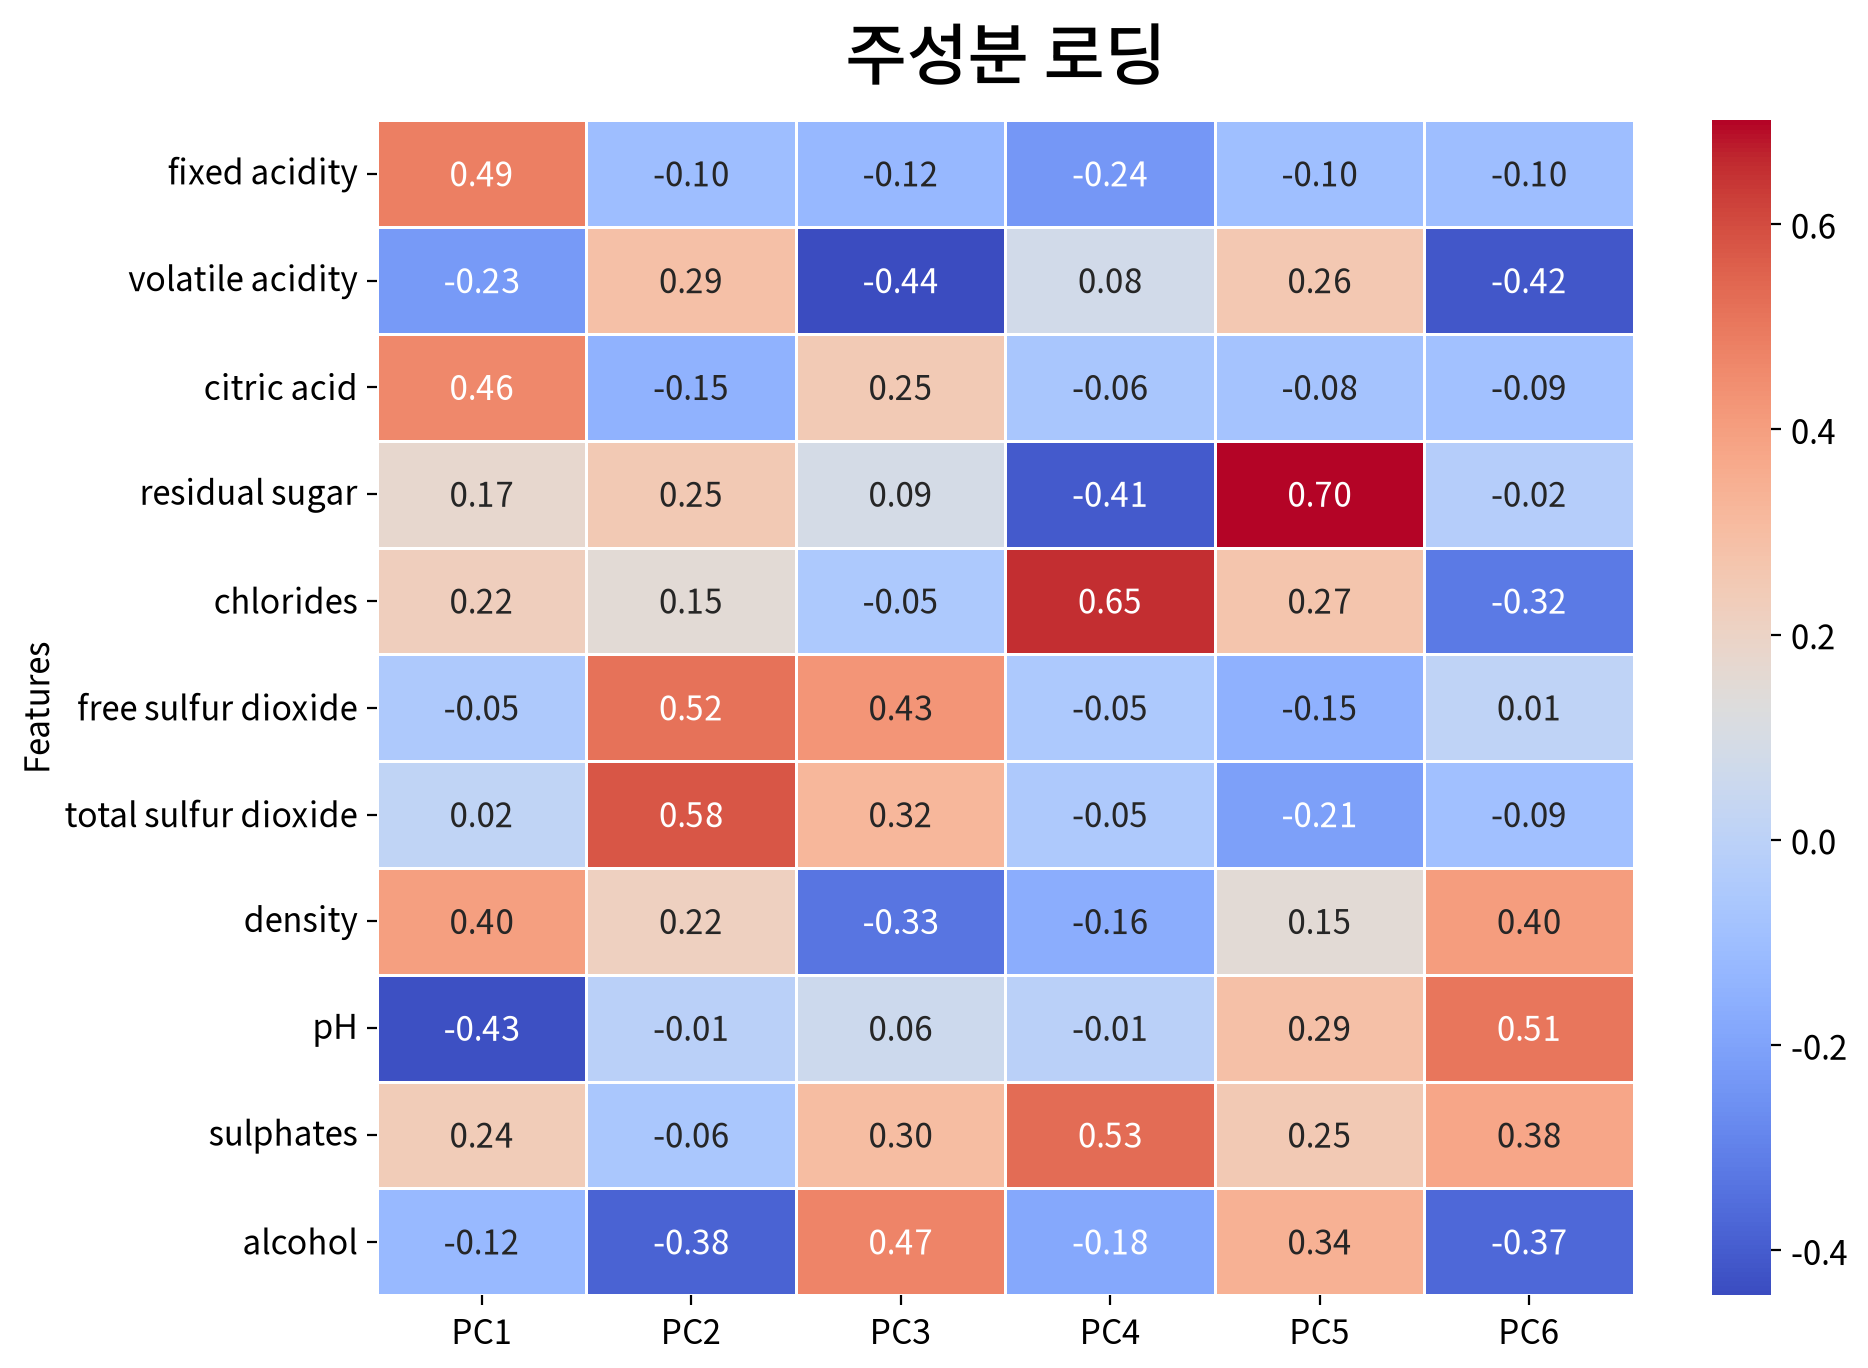

In [11]:
# 설명력 행 두 개를 뺀 순수 로딩만 히트맵으로 표시
my_plot.heatmap(data=loadings.iloc[:-2, :], fmt="0.2f", palette="coolwarm",
                title="주성분 로딩", width=1000, height=700)

| 가로 방향 | 붉은색 |
|---|---|
| PC1 ~ PC6 | 양(+)의 방향으로 큼 |

| 세로 방향 | 푸른색 |
|---|---|
| 원래 변수 11개 | 음(−)의 방향으로 큼 |

**칸의 숫자**
그 변수의 로딩 값

## #05. 바이플롯 Biplot 시각화 
### 1. 시각화에 필요한 정보 구성 

In [12]:
xname = "PC1"   # x축에 시각화 할 주성분 이름 지정
yname = "PC2"   # y축에 시각화 할 주성분 이름 지정

score = estimator.transform(sdf)      # 주성분 점수 (sdf는 표준화된 원데이터)
components = estimator.components_    # 주성분 로딩 벡터 추출

x_index = cols.index(xname)      # x축에 해당하는 주성분의 열 인덱스
y_index = cols.index(yname)      # y축에 해당하는 주성분의 열 인덱스
print(f"x_index: {x_index}, y_index: {y_index}")

xs = score[:, x_index]    # 주성분 점수에서 x축에 해당하는 주성분 점수 추출
ys = score[:, y_index]    # 주성분 점수에서 y축에 해당하는 주성분 점수 추출
print(f"xs.shape: {xs.shape}, ys.shape: {ys.shape}")

x_index: 0, y_index: 1
xs.shape: (1143,), ys.shape: (1143,)


### 2. 시각화 할 정보를 DataFrame으로 묶기 

In [13]:
# 점과 화살표의 크기를 비슷하게 맞추기 위한 축소 비율
scalex = 1.0 / (xs.max() - xs.min())
scaley = 1.0 / (ys.max() - ys.min())

# 주성분 로딩 벡터를 x, y축에 맞게 축소
vdf = DataFrame({xname: xs * scalex, yname: ys * scaley, 
                 "target": origin["quality"]})
vdf.head()

,PC1,PC2,target
0,-0.112,0.045,5
1,-0.054,0.195,5
2,-0.051,0.093,5
3,0.165,-0.023,6
4,-0.112,0.045,5


### 3. 시각화 

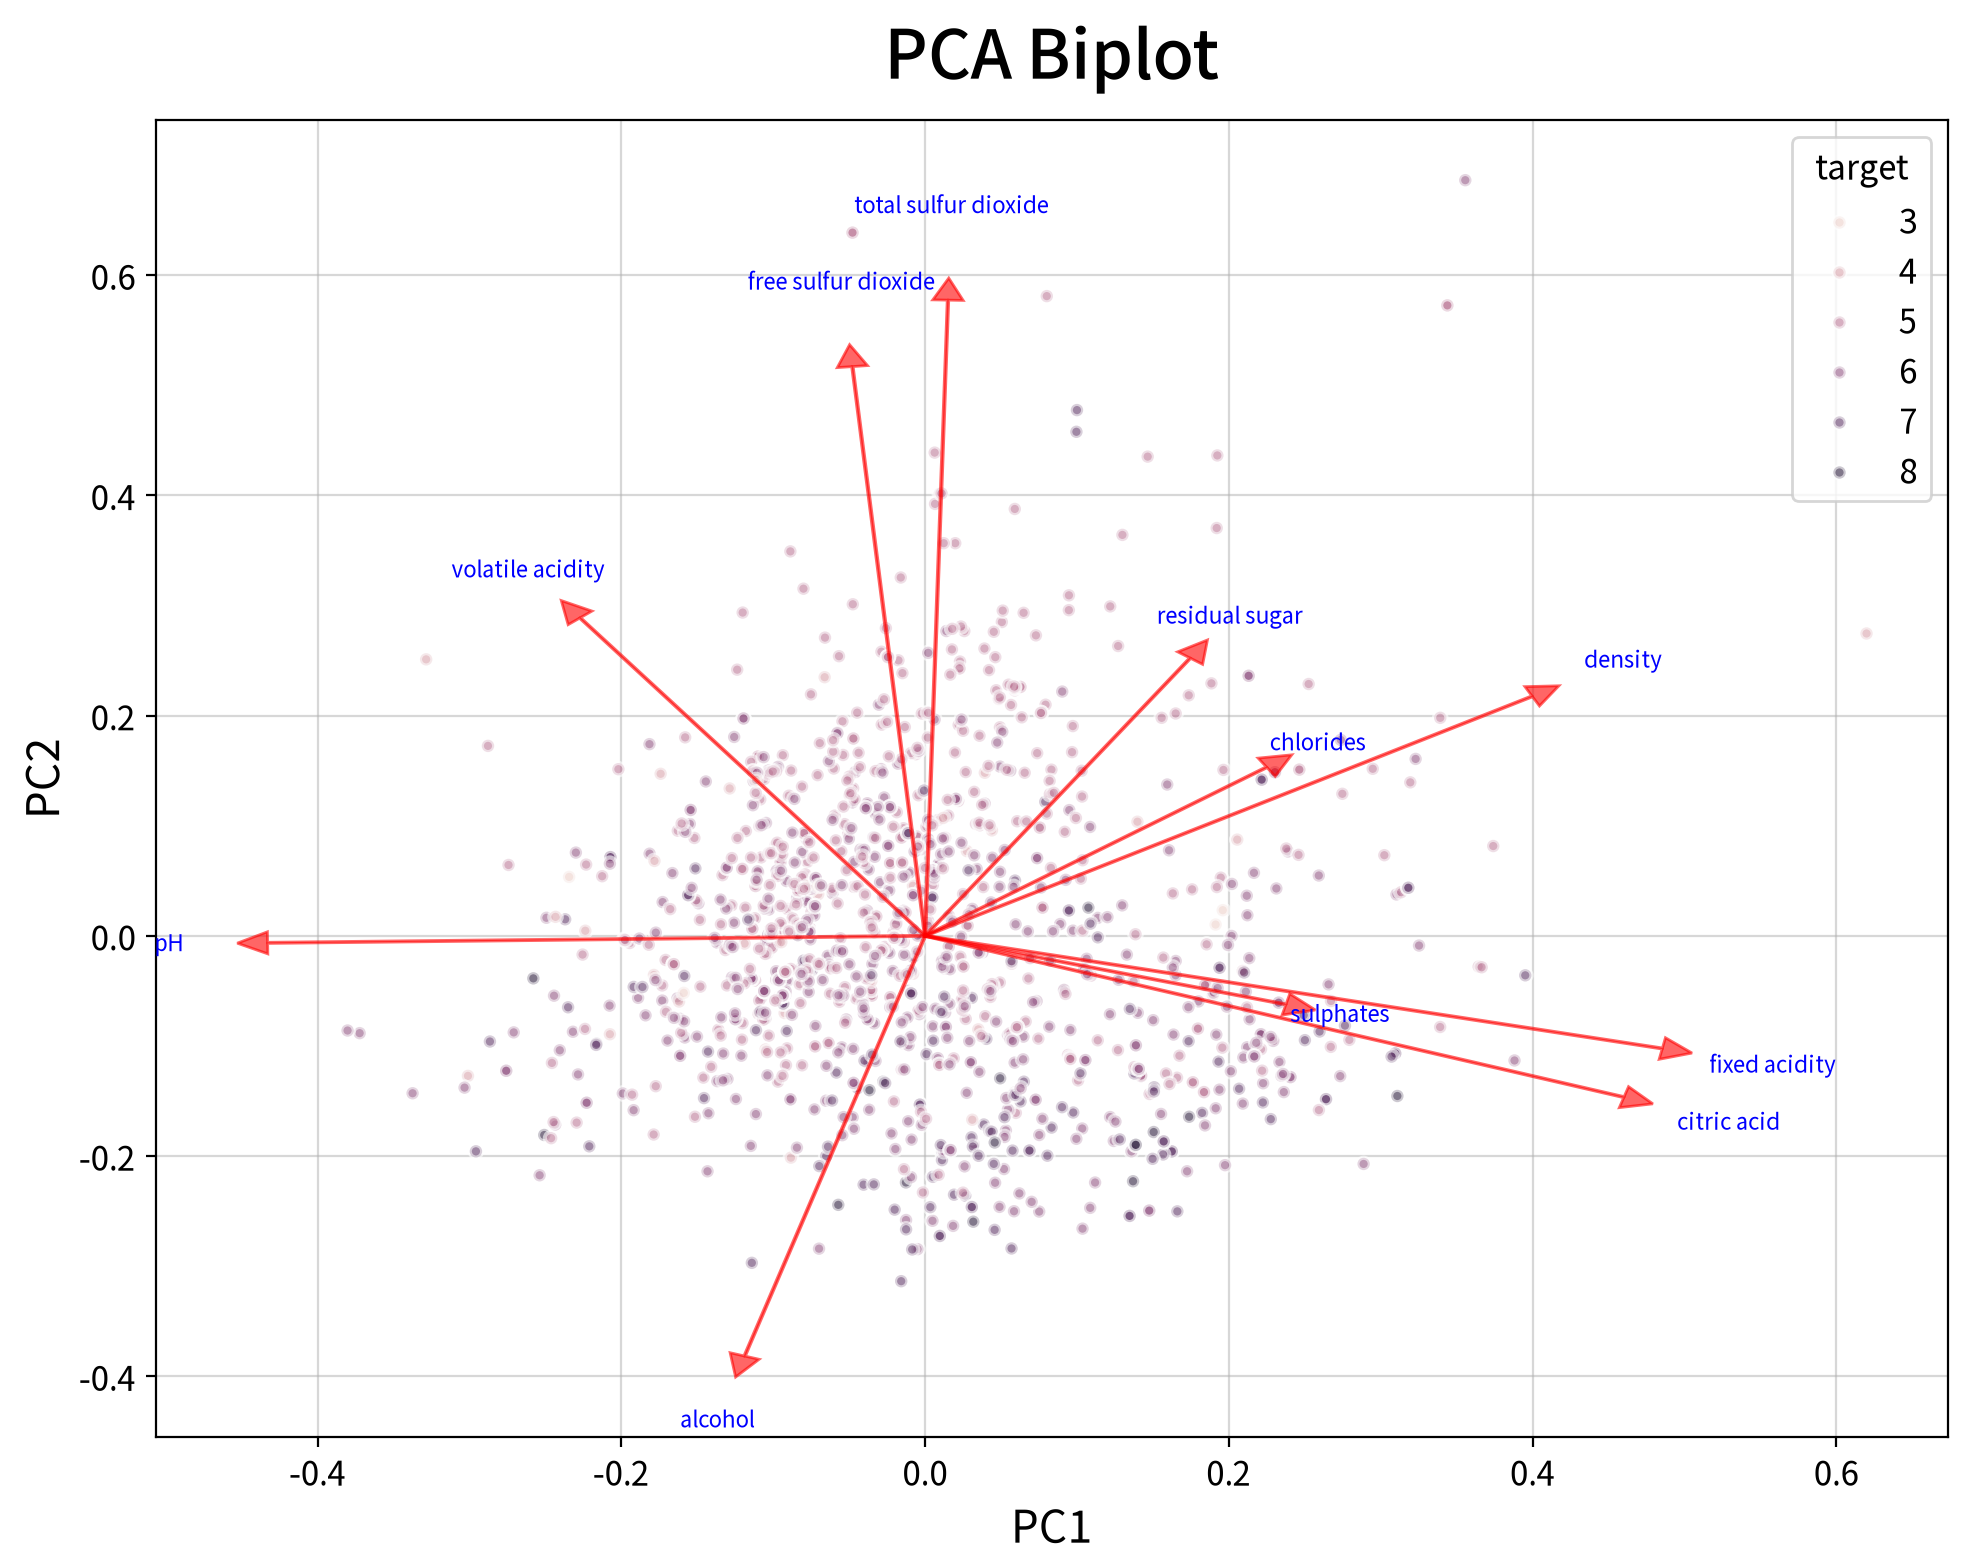

In [14]:
fig, ax = my_plot.init(title="PCA Biplot", xlabel=xname, ylabel=yname,
                       width=1000, height=800)

# 데이터 점 찍기 (품질 점수별로 색 구분)
my_plot.scatterplot(data=vdf, x=xname, y=yname, hue="target",
                    size=20, alpha=0.6, outline=False, ax=ax)

# 원래 변수 개수만큼 화살표 그리기
for i, feature in enumerate(sdf.columns):
    # 화살표 그리기
    ax.arrow(0, 0, components[x_index, i], components[y_index, i],
             color="r", alpha=0.6, head_width=0.02, head_length=0.02)
    # 변수 이름 표시
    ax.text(components[x_index, i] * 1.15, components[y_index, i] * 1.15,
            feature, color="b", fontsize=8, ha="center", va="center")

my_plot.show()

**화살표가 어느 축과 나란한가**
→ 그 주성분에 크게 기여하는 변수

**화살표의 길이**
→ 길수록 그 평면에서 영향이 큼

**화살표끼리 가까운가**
→ 가까울수록 서로 비슷하게 움직이는 변수

# 2. PCA 모듈화 

### 1. 기본 사용 

변수 11개 -> 주성분 6개(누적 설명력 85.8%)


,PC1,PC2,PC3,PC4,PC5,PC6
Features,,,,,,
fixed acidity,0.485,-0.102,-0.122,-0.236,-0.097,-0.103
volatile acidity,-0.227,0.289,-0.444,0.077,0.258,-0.416
citric acid,0.460,-0.147,0.247,-0.064,-0.078,-0.089
residual sugar,0.175,0.252,0.091,-0.407,0.701,-0.025
chlorides,0.225,0.153,-0.053,0.653,0.271,-0.319
free sulfur dioxide,-0.048,0.517,0.428,-0.051,-0.149,0.010
total sulfur dioxide,0.015,0.577,0.323,-0.047,-0.210,-0.095
density,0.400,0.218,-0.334,-0.164,0.152,0.402
pH,-0.433,-0.006,0.060,-0.007,0.289,0.507


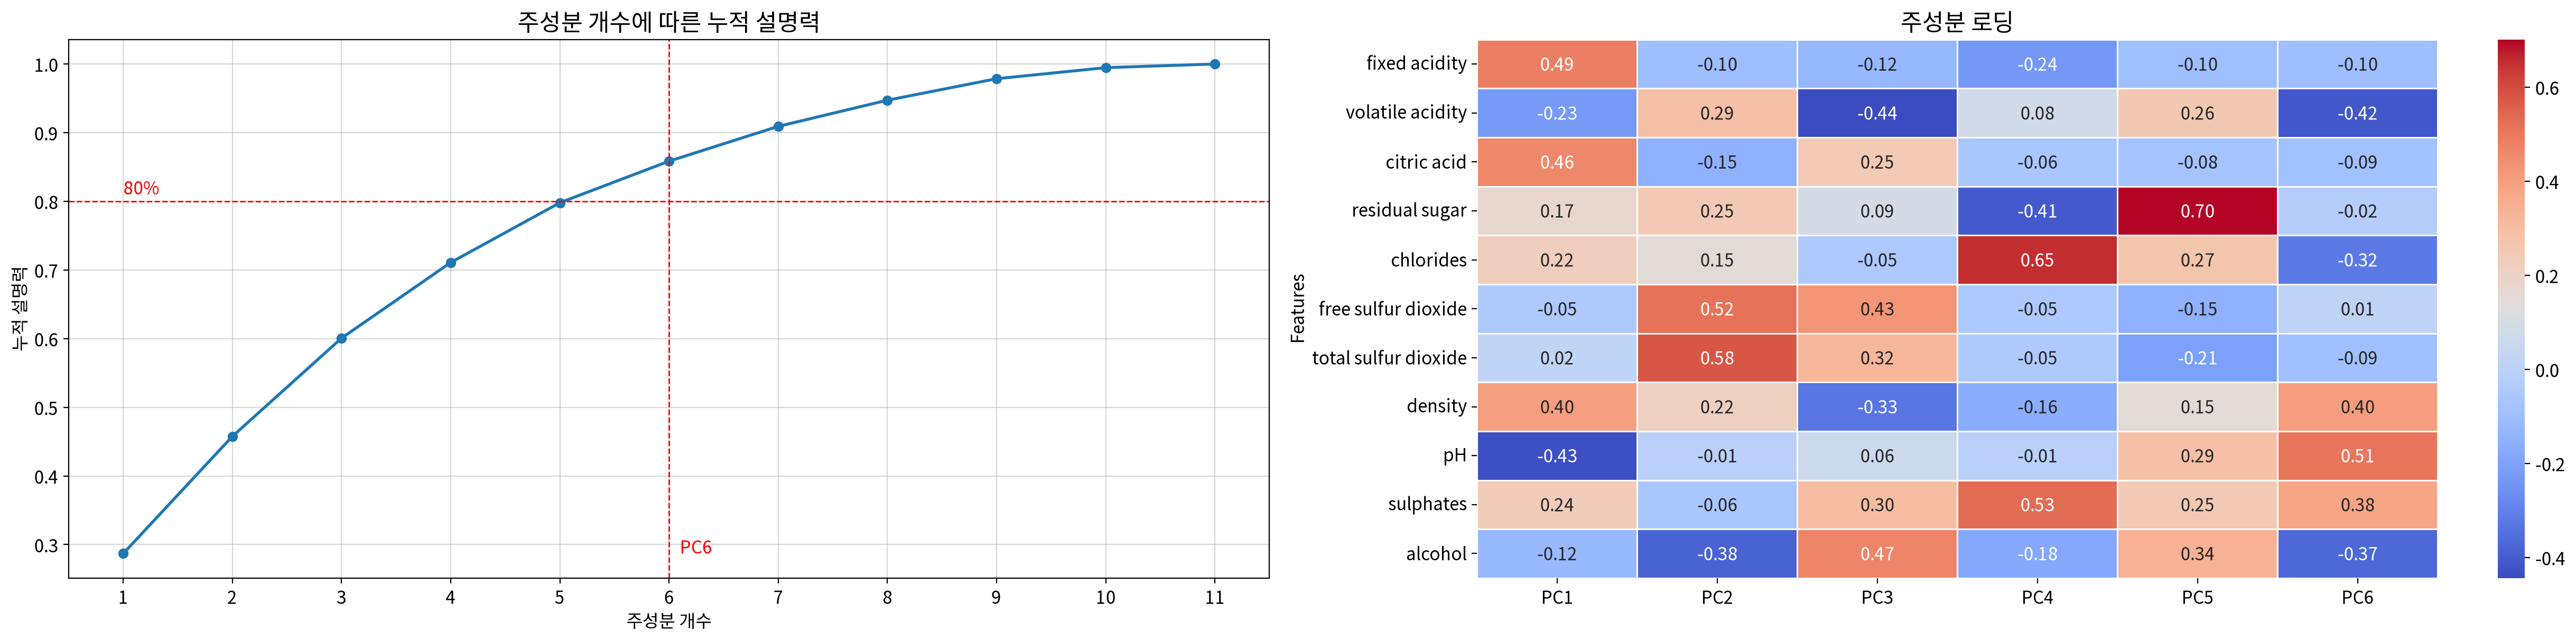

,PC1,PC2,PC3,PC4,PC5,PC6,quality
0,-1.562,0.445,-1.767,0.133,0.130,0.907,5
1,-0.761,1.915,-0.864,0.537,0.091,-0.860,5
2,-0.708,0.914,-1.142,0.435,0.025,-0.357,5
3,2.308,-0.224,0.257,-0.831,-1.639,0.155,6
4,-1.562,0.445,-1.767,0.133,0.130,0.907,5


In [15]:
pca_df = my_prep.pca(origin, y="quality")   
pca_df.head()

### 2. 바이플롯 지정 

변수 11개 -> 주성분 6개(누적 설명력 85.8%)


,PC1,PC2,PC3,PC4,PC5,PC6
Features,,,,,,
fixed acidity,0.485,-0.102,-0.122,-0.236,-0.097,-0.103
volatile acidity,-0.227,0.289,-0.444,0.077,0.258,-0.416
citric acid,0.460,-0.147,0.247,-0.064,-0.078,-0.089
residual sugar,0.175,0.252,0.091,-0.407,0.701,-0.025
chlorides,0.225,0.153,-0.053,0.653,0.271,-0.319
free sulfur dioxide,-0.048,0.517,0.428,-0.051,-0.149,0.010
total sulfur dioxide,0.015,0.577,0.323,-0.047,-0.210,-0.095
density,0.400,0.218,-0.334,-0.164,0.152,0.402
pH,-0.433,-0.006,0.060,-0.007,0.289,0.507


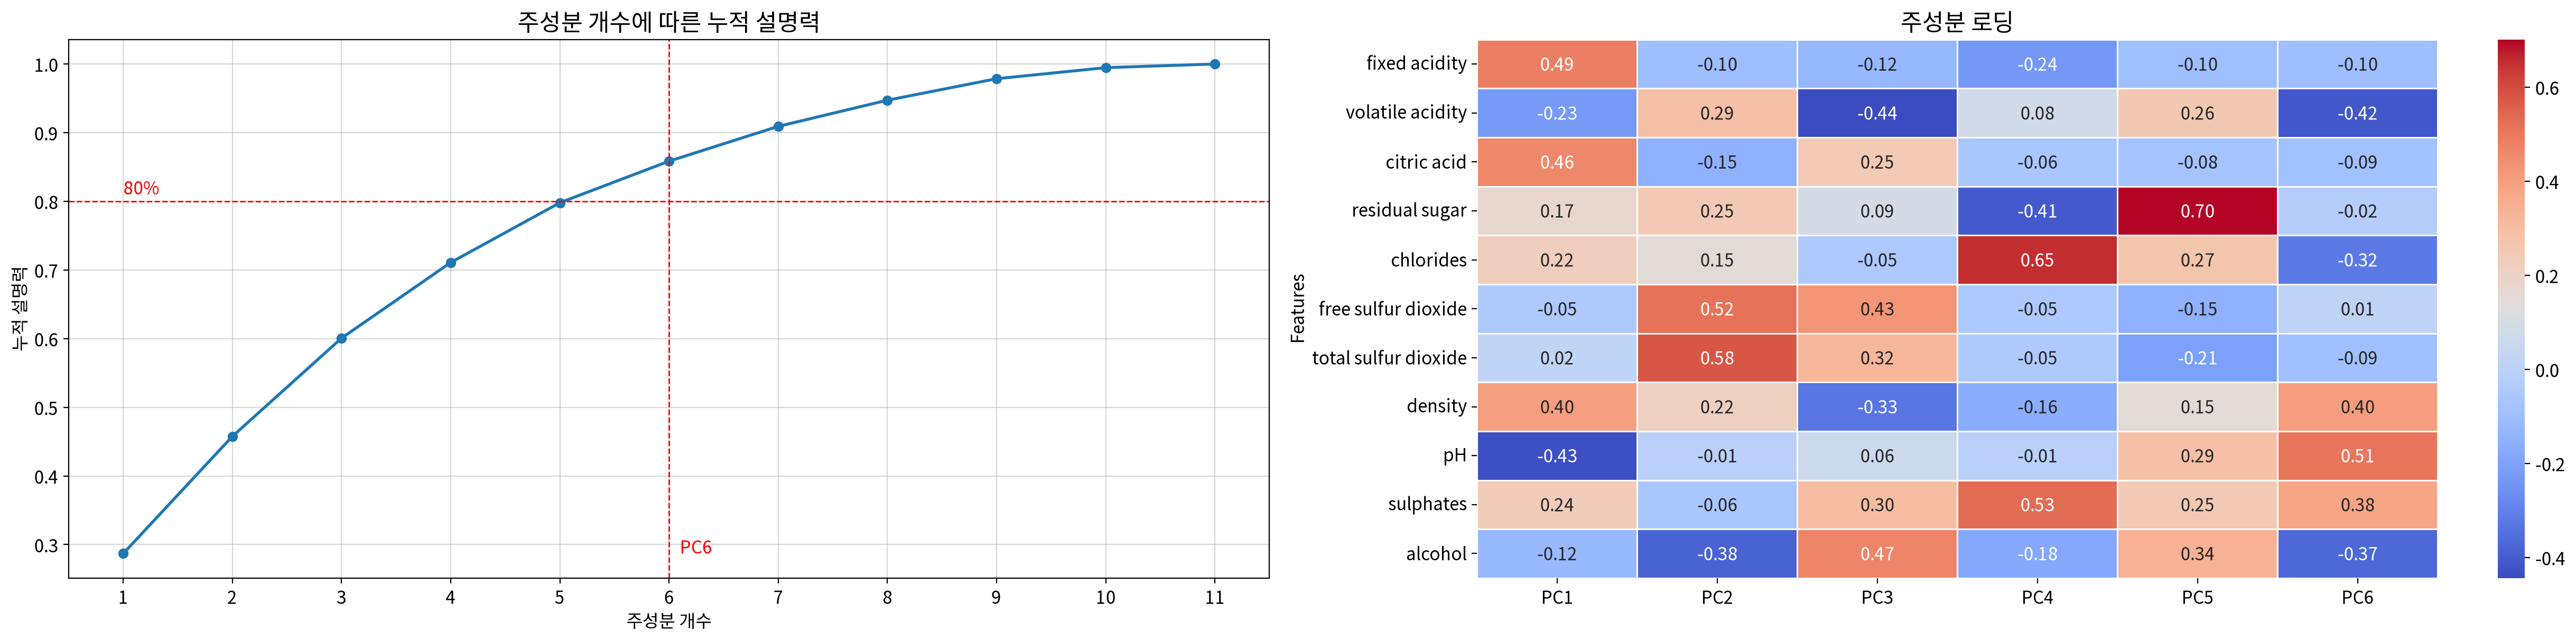

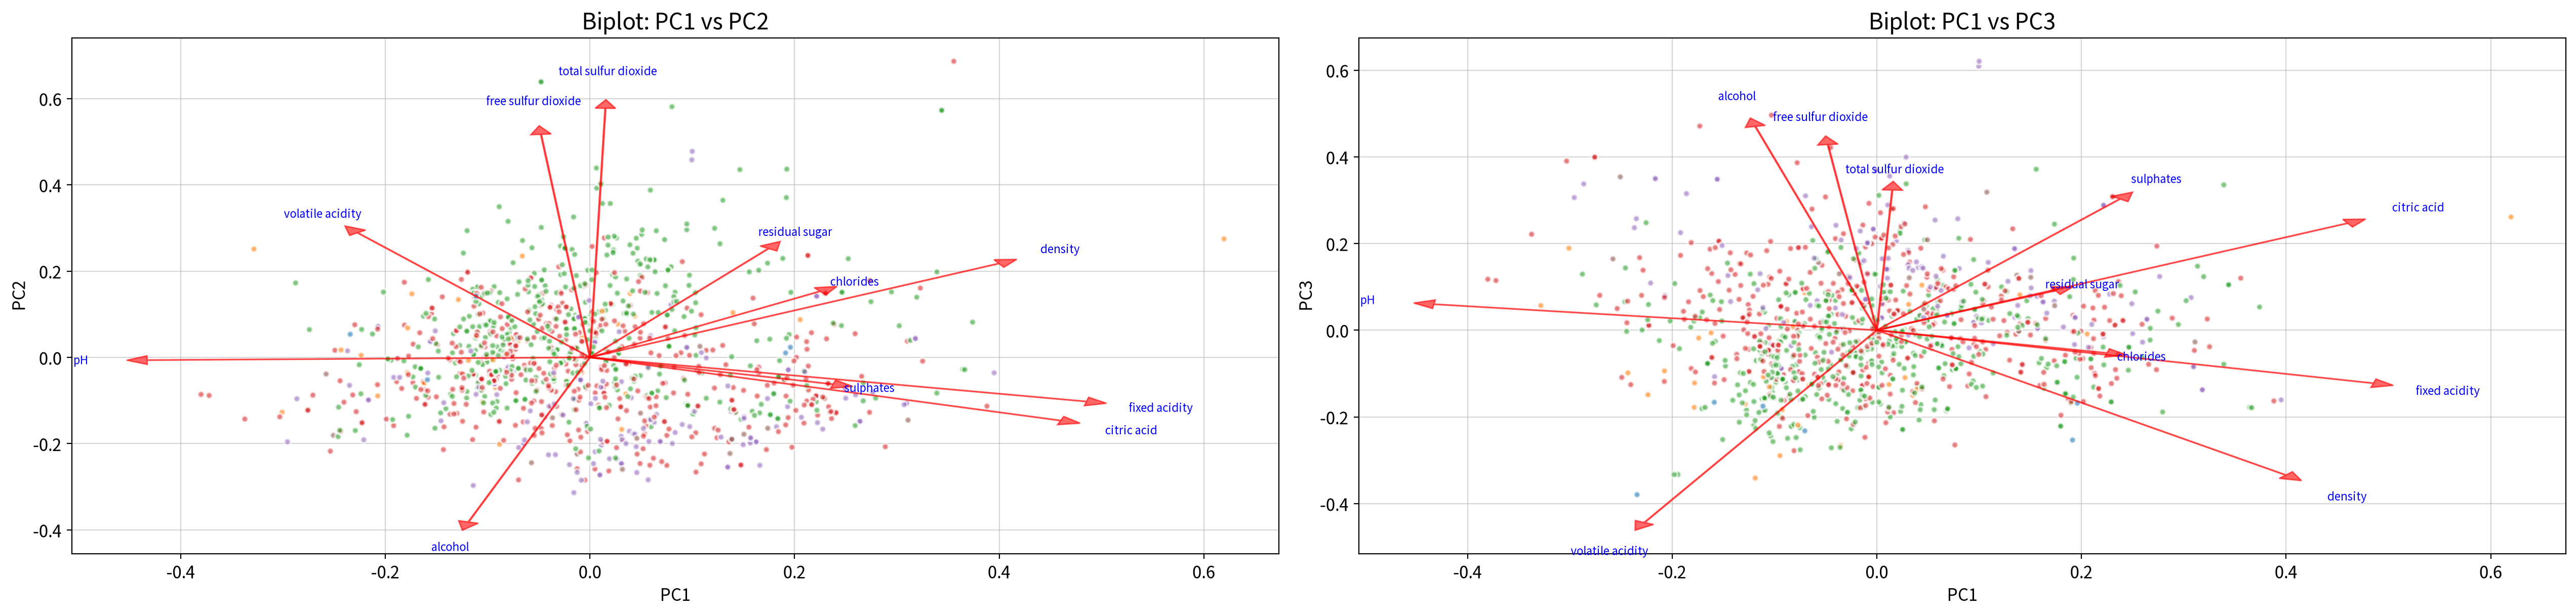

,PC1,PC2,PC3,PC4,PC5,PC6,quality
0,-1.562,0.445,-1.767,0.133,0.130,0.907,5
1,-0.761,1.915,-0.864,0.537,0.091,-0.860,5
2,-0.708,0.914,-1.142,0.435,0.025,-0.357,5
3,2.308,-0.224,0.257,-0.831,-1.639,0.155,6
4,-1.562,0.445,-1.767,0.133,0.130,0.907,5


In [16]:
pca_df = my_prep.pca(origin, y="quality", 
                     biplot=[["PC1", "PC2"], ["PC1", "PC3"]])
pca_df.head()

### 3. 주성분 수 지정 + 모든 성분의 biplot

변수 11개 -> 주성분 3개(누적 설명력 60.1%)


,PC1,PC2,PC3
Features,,,
fixed acidity,0.485,-0.102,-0.122
volatile acidity,-0.227,0.289,-0.444
citric acid,0.460,-0.147,0.247
residual sugar,0.175,0.252,0.091
chlorides,0.225,0.153,-0.053
free sulfur dioxide,-0.048,0.517,0.428
total sulfur dioxide,0.015,0.577,0.323
density,0.400,0.218,-0.334
pH,-0.433,-0.006,0.060


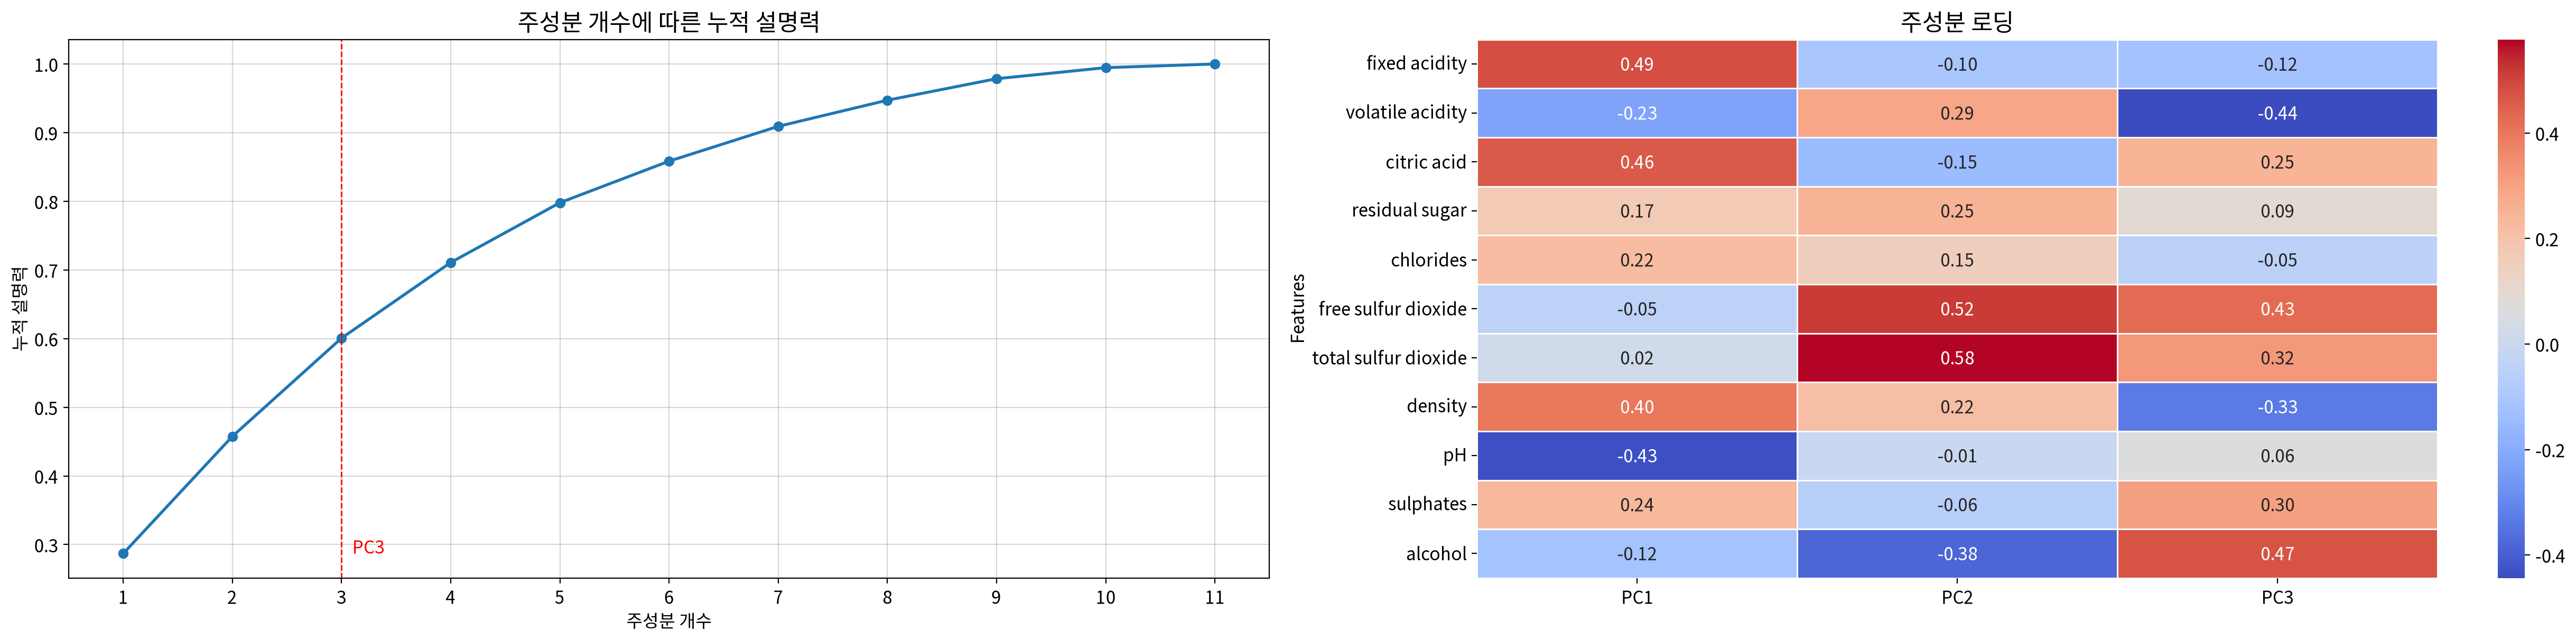

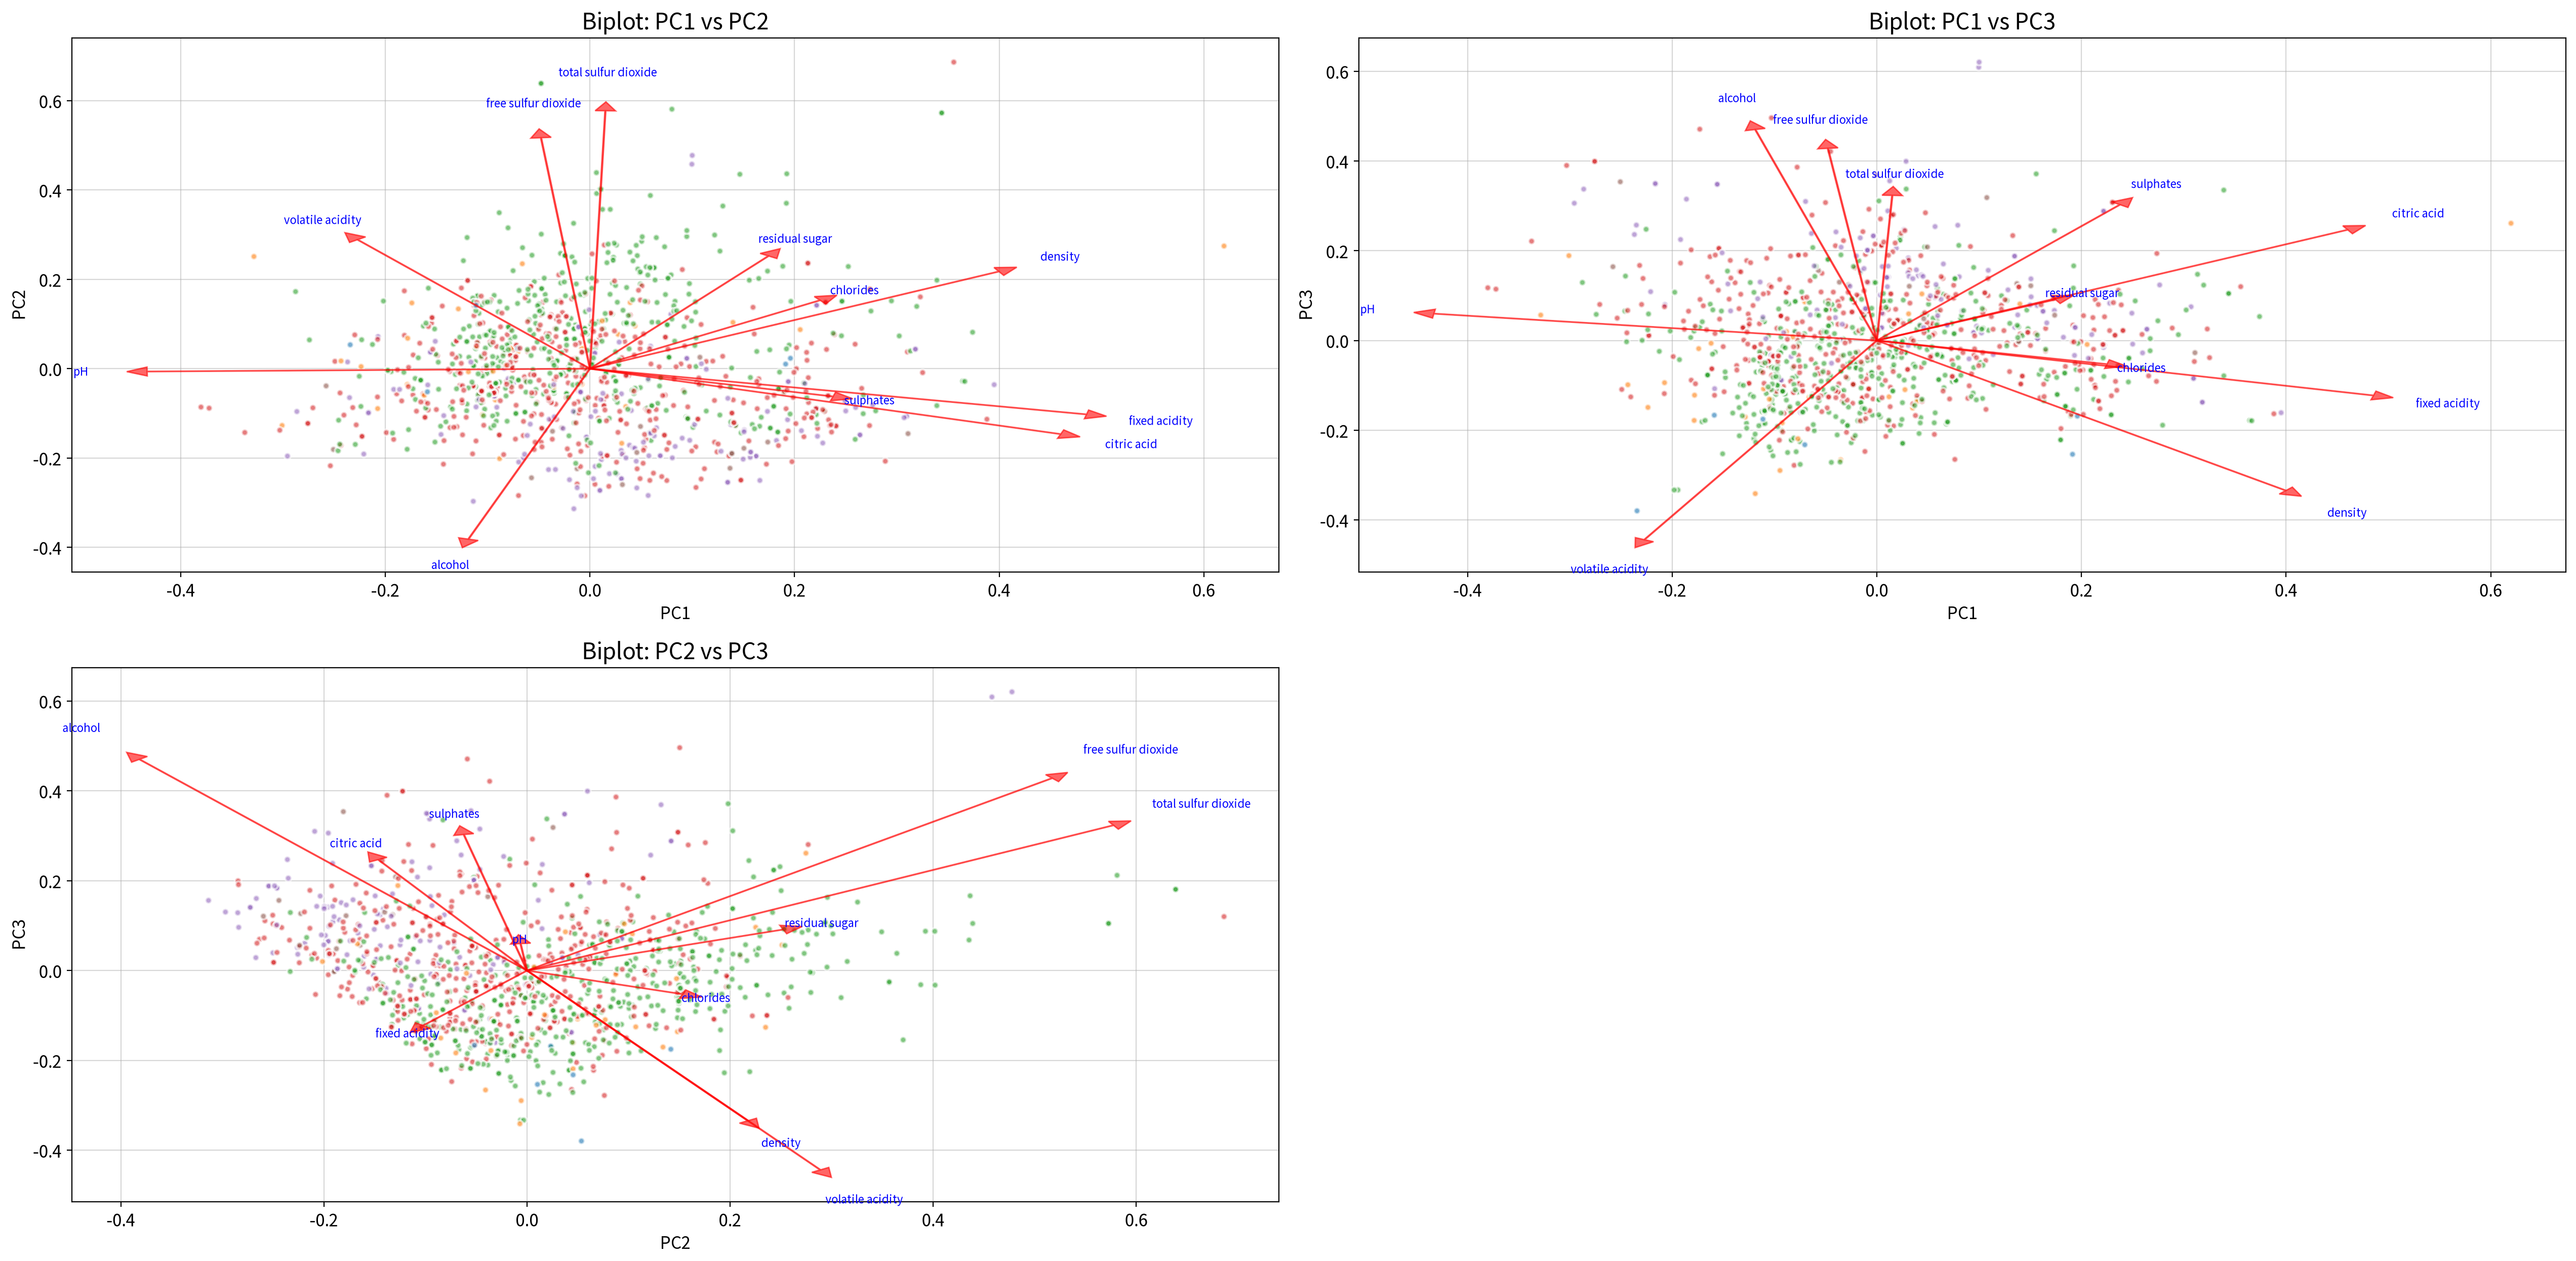

,PC1,PC2,PC3,quality
0,-1.562,0.445,-1.767,5
1,-0.761,1.915,-0.864,5
2,-0.708,0.914,-1.142,5
3,2.308,-0.224,0.257,6
4,-1.562,0.445,-1.767,5


In [17]:
pca_df = my_prep.pca(origin, y="quality", n_components=3, biplot="all")
pca_df.head()

### 4. 스케일러 변경 + biplot 없음 

변수 11개 -> 주성분 5개(누적 설명력 83.4%)


,PC1,PC2,PC3,PC4,PC5
Features,,,,,
fixed acidity,0.509,-0.049,-0.129,0.354,-0.265
volatile acidity,-0.211,-0.280,-0.152,0.445,-0.085
citric acid,0.655,0.261,0.200,-0.185,0.060
residual sugar,0.083,-0.055,0.118,0.413,0.269
chlorides,0.080,-0.080,0.017,-0.162,0.243
free sulfur dioxide,-0.075,-0.207,0.780,0.109,-0.077
total sulfur dioxide,-0.008,-0.221,0.498,0.013,-0.104
density,0.342,-0.402,-0.126,0.359,0.386
pH,-0.332,0.093,0.014,0.116,0.534


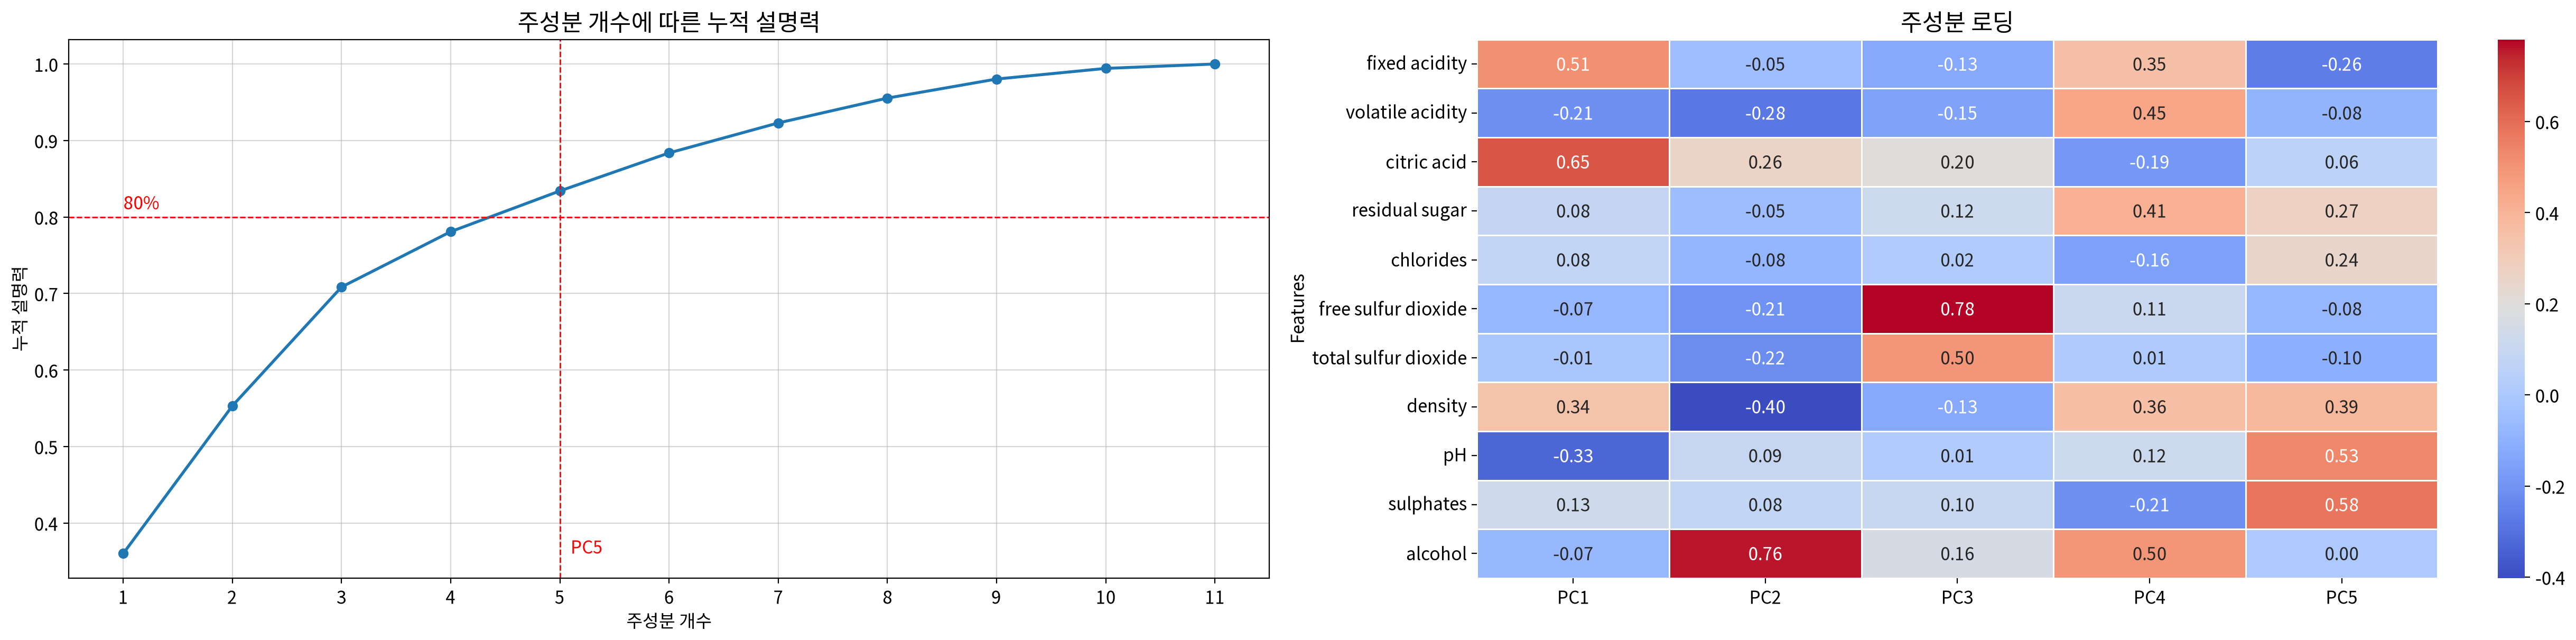

,PC1,PC2,PC3,PC4,PC5,quality
0,-0.262,-0.214,-0.179,0.029,0.069,5
1,-0.219,-0.266,0.047,0.095,-0.074,5
2,-0.179,-0.192,-0.077,0.042,-0.036,5
3,0.422,-0.026,0.053,-0.072,-0.114,6
4,-0.262,-0.214,-0.179,0.029,0.069,5


In [18]:
pca_df = my_prep.pca(origin, y="quality", method="minmax")
pca_df.head()

### 5. 보고서, 시각화 생략 

In [19]:
pca_df = my_prep.pca(origin, y="quality", report=False, plot=False)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,quality
0,-1.562,0.445,-1.767,0.133,0.130,0.907,5
1,-0.761,1.915,-0.864,0.537,0.091,-0.860,5
2,-0.708,0.914,-1.142,0.435,0.025,-0.357,5
3,2.308,-0.224,0.257,-0.831,-1.639,0.155,6
4,-1.562,0.445,-1.767,0.133,0.130,0.907,5
